In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor



In [2]:

from preprocessing import (
    clean_train_pipeline,
    get_constant_columns,
    get_feature_columns
)

from training import(
    evaluate_model,
    build_error_analysis,
    split_by_engine
)

In [3]:
train = clean_train_pipeline(
    "../data/train_FD001.txt"
)
train.shape

(20631, 27)

In [4]:
constant_cols = get_constant_columns(train)

print("Constant columns:")
print(constant_cols)

Constant columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [6]:

train_data, val_data = split_by_engine(train)

print("Train:", train_data.shape)
print("Validation:", val_data.shape)

Train: (16561, 27)
Validation: (4070, 27)


In [7]:
train_engines = set(train_data["unit_number"])
val_engines = set(val_data["unit_number"])

print("Overlap:", train_engines.intersection(val_engines))

Overlap: set()


In [8]:

feature_cols = get_feature_columns(train)

X_train = train_data[feature_cols]
y_train = train_data["RUL"]

X_val = val_data[feature_cols]
y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 18)
y_train: (16561,)
X_val: (4070, 18)
y_val: (4070,)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [10]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)

(16561, 18)
(4070, 18)


In [ ]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [12]:
y_pred = model.predict(X_val)

print(y_pred[:10])

[214.375 202.725 206.865 233.765 214.055 219.52  205.57  205.645 207.03
 205.885]


In [ ]:
baseline_results = evaluate_model(y_val, y_pred, "Random Forest")

Random Forest
MAE : 23.93874201474201
RMSE: 31.606191389735955
R²  : 0.7682340364280458


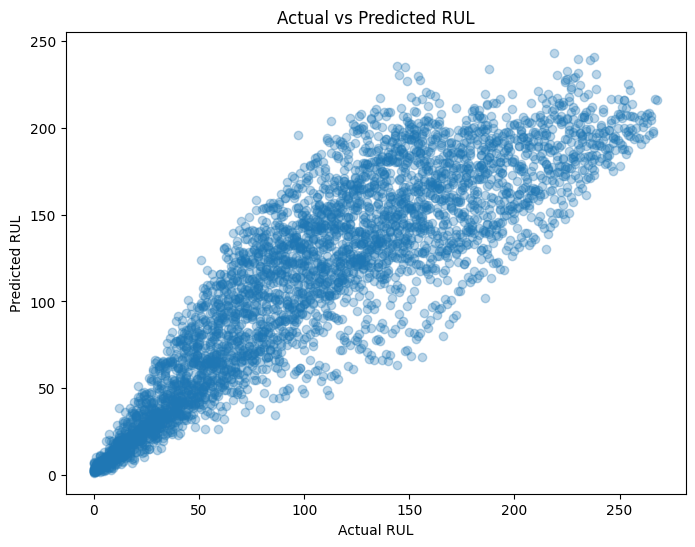

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_pred, alpha=0.3)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.show()

In [16]:
error_analysis = build_error_analysis(val_data, y_pred)


In [17]:
error_analysis[
    ["RUL", "predicted_RUL", "error", "absolute_error"]
].describe()

,RUL,predicted_RUL,error,absolute_error
count,4070.000000,4070.000000,4070.000000,4070.000000
mean,105.488698,110.919356,5.430658,23.938742
std,65.659973,60.643866,31.139967,20.639589
min,0.000000,1.325000,-87.835000,0.005000
25%,50.000000,59.940000,-9.303750,5.767500
50%,101.000000,118.305000,3.925000,17.965000
75%,153.000000,160.718750,26.401250,38.733750
max,268.000000,243.365000,98.890000,98.890000


In [18]:
error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,unit_number,time_cycles,RUL,predicted_RUL,error,absolute_error
18417,91,38,97,195.890,98.890,98.890
8650,45,14,144,235.505,91.505,91.505
8681,45,45,113,204.065,91.065,91.065
16995,84,111,156,68.165,-87.835,87.835
8646,45,10,148,234.925,86.925,86.925
16985,84,101,166,80.170,-85.830,85.830
8649,45,13,145,230.640,85.640,85.640
16936,84,52,215,130.340,-84.660,84.660
16965,84,81,186,101.890,-84.110,84.110
8672,45,36,122,205.895,83.895,83.895


In [19]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,time_cycles,0.535671
10,sensor_11,0.141243
9,sensor_9,0.045612
5,sensor_4,0.032715
13,sensor_14,0.030027
11,sensor_12,0.028131
7,sensor_7,0.023827
14,sensor_15,0.023116
17,sensor_21,0.021129
4,sensor_3,0.020045


In [20]:
X_train_time = X_train[["time_cycles"]]
X_val_time = X_val[["time_cycles"]]

time_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

time_model.fit(X_train_time, y_train)

y_pred_time = time_model.predict(X_val_time)
time_results = evaluate_model(y_val, y_pred_time, "Time-only")


Time-only
MAE : 34.7896184769228
RMSE: 39.08696575252176
R²  : 0.6455383600279079


In [21]:
feature_cols_no_time = [
    col for col in feature_cols
    if col != "time_cycles"
]

X_train_no_time = X_train[feature_cols_no_time]
X_val_no_time = X_val[feature_cols_no_time]

In [22]:
no_time_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

no_time_model.fit(X_train_no_time, y_train)

y_pred_no_time = no_time_model.predict(X_val_no_time)

In [23]:
no_time_results = evaluate_model(y_val, y_pred_no_time, "No-time")


No-time
MAE : 25.853369778869776
RMSE: 35.39071031920714
R²  : 0.7094078456777966


In [24]:

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_val)

In [25]:
linear_results = evaluate_model(y_val, y_pred_linear, "Linear Regression")


Linear Regression
MAE : 25.155167759673517
RMSE: 31.655955380900203
R²  : 0.7675036302202907


In [26]:
linear_model_scaled = LinearRegression()

linear_model_scaled.fit(
    X_train_scaled,
    y_train
)

y_pred_linear_scaled = linear_model_scaled.predict(
    X_val_scaled
)

linear_scaled_results = evaluate_model(y_val, y_pred_linear_scaled, "Scaled Linear Regression")


Scaled Linear Regression
MAE : 25.15516775967197
RMSE: 31.65595538089912
R²  : 0.7675036302203065


In [ ]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

In [28]:
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)

In [29]:
xgb_results = evaluate_model(y_val, y_pred_xgb, "XGBoost")


XGBoost
MAE : 23.57303237915039
RMSE: 31.188008826009558
R²  : 0.774326503276825


In [30]:
xgb_model_scaled = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model_scaled.fit(
    X_train_scaled,
    y_train
)

y_pred_xgb_scaled = xgb_model_scaled.predict(
    X_val_scaled
)

In [31]:
xgb_scaled_results = evaluate_model(y_val, y_pred_xgb_scaled, "XGBoost (scaled)")


XGBoost (scaled)
MAE : 23.57303237915039
RMSE: 31.188008826009558
R²  : 0.774326503276825
